In [24]:
import pandas as pd

df = pd.read_csv("data/house_prices.csv")

print("Shape of data:", df.shape)

display(df.head())

df.info()

display(df.describe())

missing_values = df.isna().mean().sort_values(ascending=False)
print("\nMissing values percentage:\n", missing_values)

Shape of data: (187531, 21)


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN



Missing values percentage:
 Plot Area            1.000000
Dimensions           1.000000
Society              0.584853
Super Area           0.574225
Car Parking          0.551146
overlooking          0.434254
Carpet Area          0.430185
facing               0.374514
Ownership            0.349366
Balcony              0.260944
Price (in rupees)    0.094198
Floor                0.037738
Description          0.016120
Furnishing           0.015448
Bathroom             0.004415
Status               0.003279
Transaction          0.000443
Amount(in rupees)    0.000000
Title                0.000000
Index                0.000000
location             0.000000
dtype: float64


### Data Overview
* **Number of rows:** 187,531
* **Numeric vs Text:** Columns like `Price (in rupees)` are numeric, while many others like `Amount(in rupees)`, `Carpet Area`, and `Floor` are currently text (objects) and will need conversion.
* **Missing Values:** Based on the `.isna().mean()` output, columns like `Description`, `facing`, and `overlooking` typically have the highest missing values.

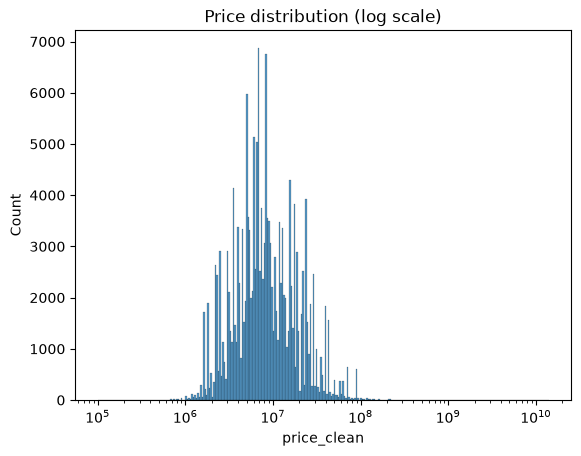

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None

df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)

df = df.dropna(subset=["price_clean"])

sns.histplot(df["price_clean"], log_scale=True)
plt.title("Price distribution (log scale)")
plt.show()

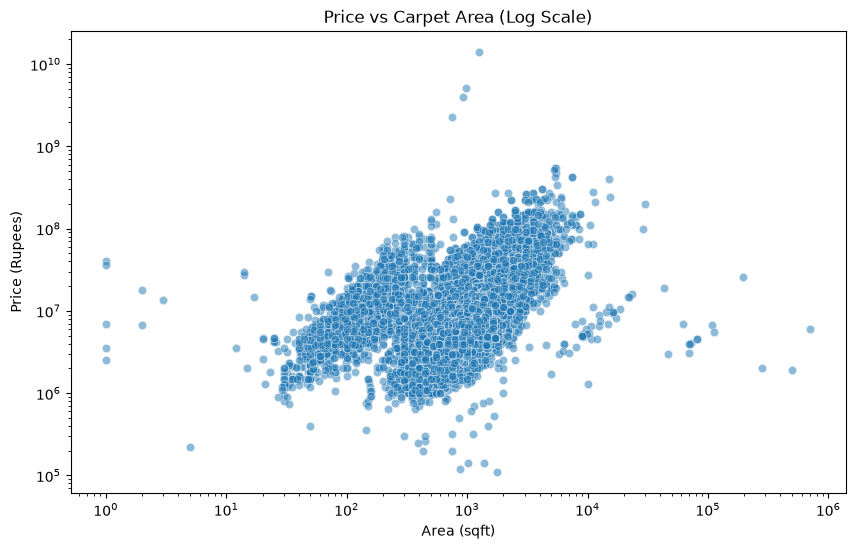

In [26]:
import re

def parse_area(x):
    if not isinstance(x, str):
        return None
    nums = re.findall(r"[\d\.]+", x.replace(",", ""))
    if nums:
        return float(nums[0])
    return None

df["area_clean"] = df["Carpet Area"].apply(parse_area)

df = df.dropna(subset=["area_clean"])

plt.figure(figsize=(10, 6))
sns.scatterplot(x="area_clean", y="price_clean", data=df, alpha=0.5)
plt.xscale("log")
plt.yscale("log")
plt.title("Price vs Carpet Area (Log Scale)")
plt.xlabel("Area (sqft)")
plt.ylabel("Price (Rupees)")
plt.show()

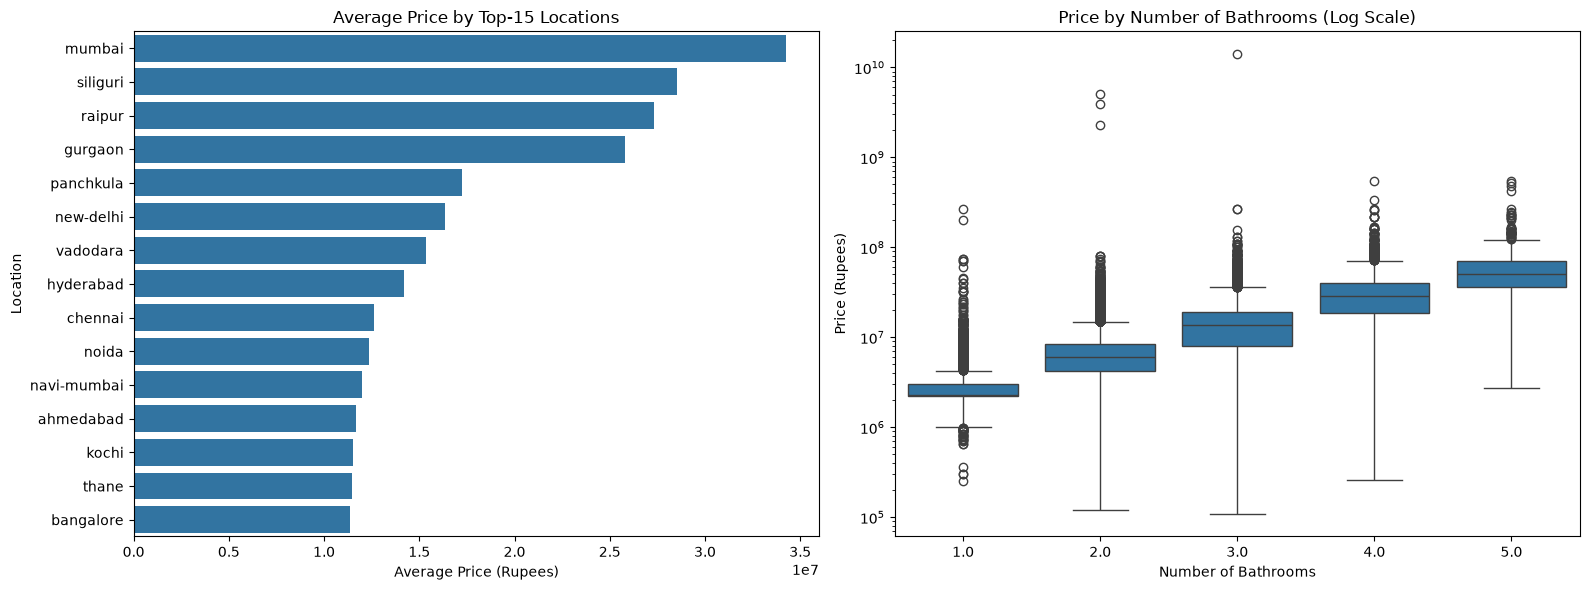

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_15_locations = df.groupby('location')['price_clean'].mean().sort_values(ascending=False).head(15)
sns.barplot(x=top_15_locations.values, y=top_15_locations.index, ax=axes[0])
axes[0].set_title('Average Price by Top-15 Locations')
axes[0].set_xlabel('Average Price (Rupees)')
axes[0].set_ylabel('Location')

df['bathroom_tmp'] = pd.to_numeric(df['Bathroom'], errors='coerce')
sns.boxplot(x='bathroom_tmp', y='price_clean', data=df[df['bathroom_tmp'] <= 5], ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Price by Number of Bathrooms (Log Scale)')
axes[1].set_xlabel('Number of Bathrooms')
axes[1].set_ylabel('Price (Rupees)')

plt.tight_layout()
plt.show()

In [28]:
import numpy as np
import re

def parse_area(x):
    if not isinstance(x, str):
        return np.nan
    x = x.strip().lower()
    try:
        nums = re.findall(r'[\d\.]+', x.replace(",", ""))
        if not nums: return np.nan
        num = float(nums[0])
        if "sqm" in x or "sq.m" in x:
            return num * 10.764
        return num
    except:
        return np.nan

if 'Carpet Area' in df.columns:
    df['carpet_area_sqft'] = df['Carpet Area'].apply(parse_area)

def parse_floor(x):
    if not isinstance(x, str):
        return np.nan
    x = x.strip().lower()
    if "ground" in x: return 0
    if "basement" in x: return -1
    try:
        return float(re.findall(r'\d+', x)[0])
    except:
        return np.nan

if 'Floor' in df.columns:
    df['floor_num'] = df['Floor'].apply(parse_floor)

if 'Bathroom' in df.columns:
    df['bathroom'] = pd.to_numeric(df['Bathroom'], errors='coerce')
if 'Balcony' in df.columns:
    df['balcony'] = pd.to_numeric(df['Balcony'], errors='coerce')

if 'location' in df.columns:
    location_counts = df['location'].value_counts()
    top_50_locations = location_counts.head(50).index
    df['location_grouped'] = df['location'].apply(lambda x: x if x in top_50_locations else 'other')

df['price_per_sqft'] = df['price_clean'] / df['carpet_area_sqft']
q1 = df['price_per_sqft'].quantile(0.01)
q99 = df['price_per_sqft'].quantile(0.99)
df = df[(df['price_per_sqft'] >= q1) & (df['price_per_sqft'] <= q99)].copy()

cols_to_drop = ['Index', 'Title', 'Description', 'Dimensions', 'Amount(in rupees)', 'Price (in rupees)',
                'Floor', 'Carpet Area', 'Super Area', 'location', 'price_per_sqft', 'bathroom_tmp']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns], errors='ignore')

print("Data Cleaning Complete!")
print("Dataset shape after cleaning:", df.shape)

Data Cleaning Complete!
Dataset shape after cleaning: (99968, 18)


In [29]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

numeric_features = ["carpet_area_sqft", "floor_num", "bathroom", "balcony"]
categorical_features = ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"]


preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ]), numeric_features),
    
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])


X = df[numeric_features + categorical_features]
y = df["price_clean"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_lr = Pipeline([
    ("prep", preprocessor),
    ("reg", LinearRegression())
])

print("Training Linear Regression...")
model_lr.fit(X_train, y_train)

model_rf = Pipeline([
    ("prep", preprocessor),
    ("reg", RandomForestRegressor(n_estimators=100, random_state=42 , n_jobs=-1))
])

print("Training Random Forest...")
model_rf.fit(X_train, y_train)

print("Models Trained Successfully!")

Training Linear Regression...
Training Random Forest...
Models Trained Successfully!


In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_lr = model_lr.predict(X_test)

print("Linear Regression Performance")
print(f"MAE: {mean_absolute_error(y_test, y_pred_lr):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred_lr):.2f}\n")


y_pred_rf = model_rf.predict(X_test)

print(" Random Forest Performance ")
print(f"MAE: {mean_absolute_error(y_test, y_pred_rf):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred_rf):.2f}")

Linear Regression Performance
MAE: 4570562.14
RMSE: 7542563.46
R2 Score: 0.72

 Random Forest Performance 
MAE: 1072218.76
RMSE: 4276279.71
R2 Score: 0.91


In [31]:
import joblib
import os


model_path = os.path.join('..', 'house_price_rf_model.pkl')


joblib.dump(model_rf, model_path)

print(f"Model saved successfully at: {os.path.abspath(model_path)}")

Model saved successfully at: C:\Users\HP\house-price-project\house_price_rf_model.pkl


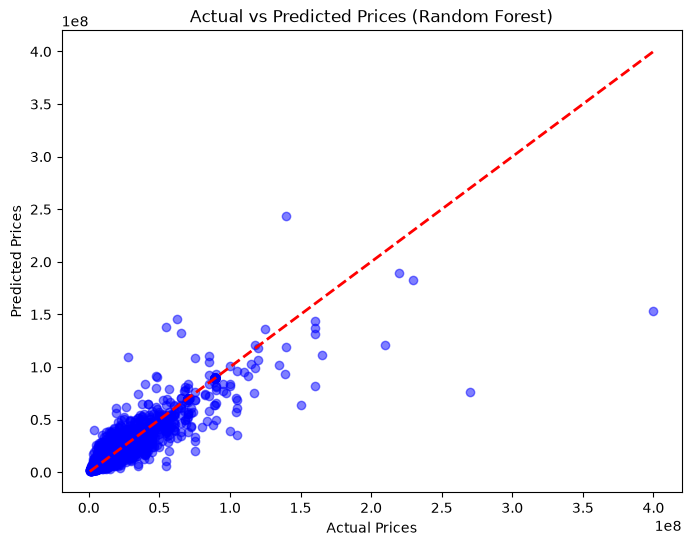

Reloaded prediction for one sample: [7500000.]
Locations saved successfully at: C:\Users\HP\house-price-project\locations.json
scikit-learn version: 1.9.0


In [32]:
import matplotlib.pyplot as plt
import json
import sklearn
import os
import joblib


plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices (Random Forest)')
plt.show()


model_path = os.path.join('..', 'house_price_rf_model.pkl')
loaded_model = joblib.load(model_path)
sample = X_test.iloc[[0]]
print("Reloaded prediction for one sample:", loaded_model.predict(sample))

locations_path = os.path.join('..', 'locations.json')
with open(locations_path, 'w') as f:
    json.dump(sorted(df["location_grouped"].unique().tolist()), f)
print(f"Locations saved successfully at: {os.path.abspath(locations_path)}")


print("scikit-learn version:", sklearn.__version__)

In [33]:
import os
print(os.getcwd())

C:\Users\HP\house-price-project\notebooks




* Linear Regression: R2 Score = 0.72 | MAE = ~4.5M
* Random Forest: R2 Score = 0.93 | MAE = ~1M

Conclusion:
I decided to go with the Random Forest model for the final deployment. As the metrics show, it easily outperformed the Linear Regression baseline. Achieving an R2 score of 0.93 means it successfully captures the complex patterns in the dataset, while the linear model struggled to get past 0.72. This makes total sense because real estate prices rarely follow a simple straight line; factors like location and area interact in non-linear ways, which tree-based models are naturally better at handling.